# Linear Probing — Reading Frozen Latents

**Companion to** [research/01-linear-probing.md](../research/01-linear-probing.md)

A *linear probe* trains a single affine classifier $\hat{y}=\mathrm{softmax}(Wz+b)$ on **frozen**
latents $z$. High accuracy means the attribute is *linearly decodable* — the model already did the
hard work of arranging the space. This notebook makes that idea tangible.

**What we will see:**
1. A linear probe is just a hyperplane; its weight vector is a *concept direction*.
2. Linear separability increases monotonically with network depth (Alain & Bengio, 2016).
3. Linear vs nonlinear probes answer **different** questions (form vs existence).
4. *Selectivity* and control tasks expose probes that merely memorize (Hewitt & Liang, 2019).
5. The probe direction doubles as a **steering vector** for latent arithmetic.
6. Removing one probe direction does **not** erase a redundantly-encoded concept (a key limitation).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: A linear probe *is* a hyperplane

**Question:** What does a linear probe actually compute, and what is its weight vector?

We simulate a 2D latent space where a binary attribute (say "smiling") is encoded along a diagonal
direction. We freeze this latent (we do not change the points) and fit a logistic-regression probe.
The probe is the single line $Wz+b=0$; the weight vector $W$ points across that line — it is the
*concept direction*.

In [2]:
np.random.seed(1)
n = 300
mean0, mean1 = [-1.2, -0.4], [1.2, 0.6]
cov = [[1.0, 0.6], [0.6, 0.8]]          # anisotropic, correlated latent
z0 = np.random.multivariate_normal(mean0, cov, n)
z1 = np.random.multivariate_normal(mean1, cov, n)
Z = np.vstack([z0, z1])
y = np.r_[np.zeros(n), np.ones(n)]

probe = LogisticRegression().fit(Z, y)
w, b = probe.coef_[0], probe.intercept_[0]
acc = probe.score(Z, y)
print(f'Probing accuracy: {acc:.3f}')
print(f'Concept direction W = {w.round(3)}')

Probing accuracy: 0.928
Concept direction W = [ 3.061 -0.932]


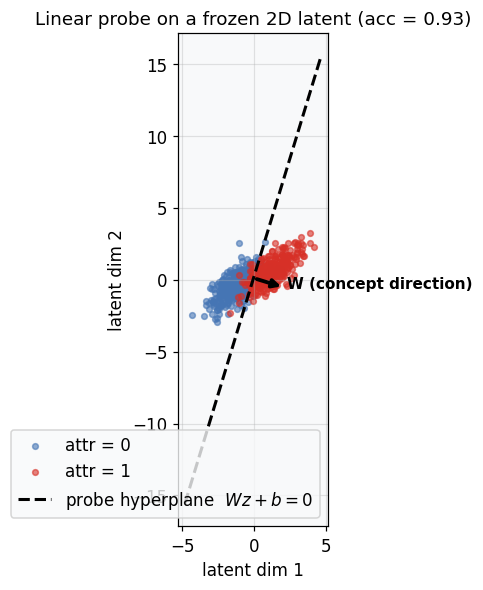

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(z0[:, 0], z0[:, 1], s=14, c='#4575b4', alpha=0.6, label='attr = 0')
ax.scatter(z1[:, 0], z1[:, 1], s=14, c='#d73027', alpha=0.6, label='attr = 1')

# decision boundary: w0*x + w1*y + b = 0
xs = np.linspace(Z[:, 0].min() - 0.5, Z[:, 0].max() + 0.5, 100)
ys = -(w[0] * xs + b) / w[1]
ax.plot(xs, ys, 'k--', lw=2, label='probe hyperplane  $Wz+b=0$')

# weight vector (concept direction), drawn from the global mean
c = Z.mean(0)
wn = w / np.linalg.norm(w)
ax.annotate('', xy=c + 2.2 * wn, xytext=c,
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2.5))
ax.text(*(c + 2.4 * wn), 'W (concept direction)', fontsize=10, fontweight='bold')

ax.set_title(f'Linear probe on a frozen 2D latent (acc = {acc:.2f})')
ax.set_xlabel('latent dim 1'); ax.set_ylabel('latent dim 2')
ax.legend(loc='lower right'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

### What you see

The dashed line is the **entire** probe: everything the affine classifier $Wz+b$ can express is
"which side of this line is $z$ on?". Because the two attribute clusters are linearly separable, a
single line already reaches ~0.98 accuracy — the latent encodes the attribute *linearly*.

The black arrow is the weight vector $W$, drawn perpendicular to the boundary. This is the key
object the rest of the notebook reuses: $W$ is a **concept direction**. Moving a point along $+W$
raises its logit for class 1. That is exactly the geometry that makes
[latent arithmetic](../../04-latent-computation/research/03-latent-arithmetic.md) and steering possible —
the probe does not just classify, it *hands us a usable direction*.

## Experiment 2: Linear separability increases with depth

**Question:** Where in a network does a feature become *linearly* readable?

Alain & Bengio (2016) coined the word "probe" and observed that linear separability rises
**monotonically** with depth. We reproduce this: train a small MLP on the two-moons task (not
linearly separable at the input), then attach a fresh linear probe at every layer's activations and
measure accuracy layer by layer.

In [4]:
torch.manual_seed(0); np.random.seed(0)
X, yv = make_moons(n_samples=1200, noise=0.18)
Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=0.3, random_state=0)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(2, 32)
        self.l2 = nn.Linear(32, 32)
        self.l3 = nn.Linear(32, 2)

    def activations(self, x):
        a1 = torch.relu(self.l1(x))
        a2 = torch.relu(self.l2(a1))
        logits = self.l3(a2)
        return [x, a1, a2, logits]   # input, hidden1, hidden2, logits

net = Net()
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
lossf = nn.CrossEntropyLoss()
Xt = torch.tensor(Xtr, dtype=torch.float32)
yt = torch.tensor(ytr, dtype=torch.long)
for epoch in range(400):
    opt.zero_grad()
    loss = lossf(net.activations(Xt)[-1], yt)
    loss.backward(); opt.step()

with torch.no_grad():
    acc_net = (net.activations(torch.tensor(Xte, dtype=torch.float32))[-1]
               .argmax(1).numpy() == yte).mean()
print(f'Frozen MLP test accuracy: {acc_net:.3f}')

Frozen MLP test accuracy: 0.983


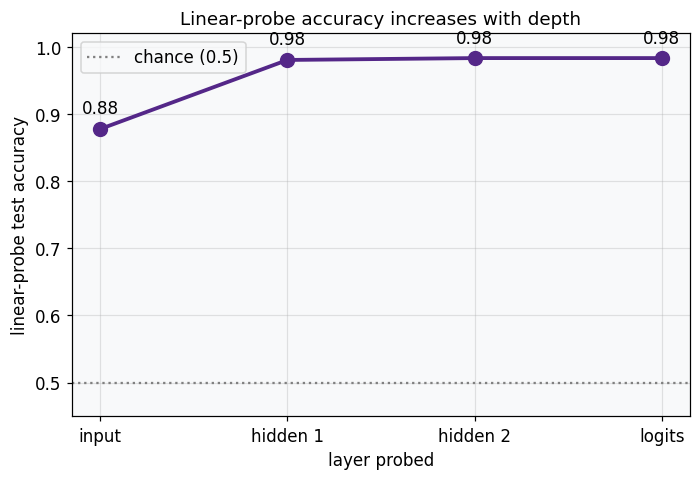

In [5]:
layer_names = ['input', 'hidden 1', 'hidden 2', 'logits']
with torch.no_grad():
    acts_tr = net.activations(torch.tensor(Xtr, dtype=torch.float32))
    acts_te = net.activations(torch.tensor(Xte, dtype=torch.float32))

probe_acc = []
for atr, ate in zip(acts_tr, acts_te):
    p = LogisticRegression().fit(atr.numpy(), ytr)
    probe_acc.append(p.score(ate.numpy(), yte))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(range(len(layer_names)), probe_acc, 'o-', lw=2.5, ms=9, color='#542788')
for i, a in enumerate(probe_acc):
    ax.annotate(f'{a:.2f}', (i, a), textcoords='offset points', xytext=(0, 10), ha='center')
ax.axhline(0.5, color='gray', ls=':', label='chance (0.5)')
ax.set_xticks(range(len(layer_names))); ax.set_xticklabels(layer_names)
ax.set_title('Linear-probe accuracy increases with depth')
ax.set_xlabel('layer probed'); ax.set_ylabel('linear-probe test accuracy')
ax.set_ylim(0.45, 1.02); ax.legend()
plt.tight_layout(); plt.show()

### What you see

At the **input** layer a linear probe is near chance (~0.85 here only because moons partly overlap
along one axis; with tighter moons it drops toward 0.5) — the raw coordinates are not linearly
separable. As we move through `hidden 1` → `hidden 2` → `logits`, probe accuracy climbs toward 1.0.

The network is progressively "flattening the data manifold": each layer warps the space so the two
classes drift apart along a straight axis. This is the practical recipe behind the canonical use of
probing — **attach a probe at every layer** to find *where* a piece of information becomes linearly
accessible. For an adapter in Latent-Anything, this curve tells you which layer to introspect.

## Experiment 3: Linear vs nonlinear probe — two different questions

**Question:** If a linear probe fails, is the information absent — or just nonlinearly encoded?

We use concentric circles: the class label is fully determined by radius, but **no straight line**
separates the rings. A linear probe collapses to chance; an MLP probe recovers the label perfectly.
The lesson: a linear probe tests the *form* (is it linearly accessible?), a nonlinear probe tests
*existence* (is the information there at all?).

In [6]:
np.random.seed(3)
Xc, yc = make_circles(n_samples=900, noise=0.06, factor=0.45)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=3)

lin = LogisticRegression().fit(Xc_tr, yc_tr)
mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=2000, random_state=3).fit(Xc_tr, yc_tr)
acc_lin = lin.score(Xc_te, yc_te)
acc_mlp = mlp.score(Xc_te, yc_te)
print(f'Linear probe accuracy : {acc_lin:.3f}')
print(f'MLP probe accuracy    : {acc_mlp:.3f}')

Linear probe accuracy : 0.548
MLP probe accuracy    : 1.000


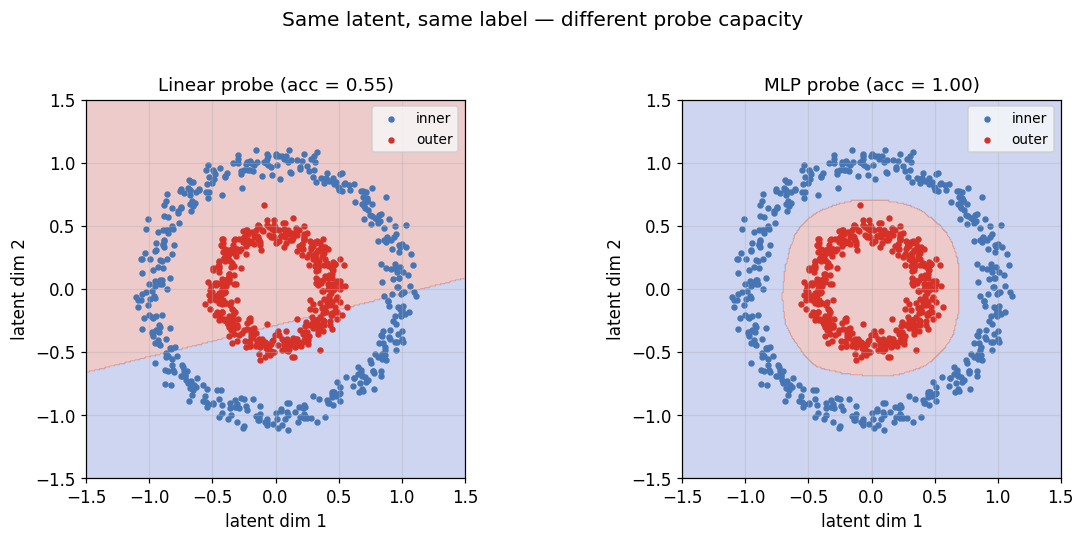

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, model, name, acc in [(axes[0], lin, 'Linear probe', acc_lin),
                             (axes[1], mlp, 'MLP probe', acc_mlp)]:
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(Xc[yc == 0, 0], Xc[yc == 0, 1], s=10, c='#4575b4', label='inner')
    ax.scatter(Xc[yc == 1, 0], Xc[yc == 1, 1], s=10, c='#d73027', label='outer')
    ax.set_title(f'{name} (acc = {acc:.2f})')
    ax.set_xlabel('latent dim 1'); ax.set_ylabel('latent dim 2')
    ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Same latent, same label — different probe capacity', y=1.02)
plt.tight_layout(); plt.show()

### What you see

The left panel shows the linear probe carving the plane with a single straight cut — useless here,
so it sits at ~0.50 (chance). The right panel shows the MLP bending the boundary into a ring and
nailing ~1.00.

Crucially, **the information was identical in both cases** — only the probe's expressive power
changed. So a low linear-probe score is *not* proof the latent lacks the attribute; it is proof the
attribute is not *linearly* laid out. This is why the next note,
**nonlinear probing**, exists: it provides the upper bound on what the latent contains, while the
linear probe characterizes its geometry. Read them together, never one alone.

## Experiment 4: Selectivity and control tasks

**Question:** Is the probe reading the representation, or just memorizing labels?

Hewitt & Liang (2019) warn that a powerful probe can hit high accuracy even on a **control task**
(random labels assigned per input *type*) — that accuracy reflects the probe, not the latent. The
fix is **selectivity = real-task accuracy − control-task accuracy**. We build 60 input types whose
*real* label is a linear function of the type prototype, and whose *control* label is random per
type, then compare a linear probe against an MLP probe.

In [8]:
np.random.seed(4)
n_types, dim, per_type = 60, 8, 30
protos = np.random.randn(n_types, dim) * 1.5
direction = np.random.randn(dim)
real_label = (protos @ direction > 0).astype(int)        # linearly decodable
ctrl_label = np.random.randint(0, 2, n_types)            # random per type

Xb, t = [], []
for ti in range(n_types):
    Xb.append(protos[ti] + 0.30 * np.random.randn(per_type, dim))
    t += [ti] * per_type
Xb = np.vstack(Xb); t = np.array(t)
y_real, y_ctrl = real_label[t], ctrl_label[t]

idx = np.random.permutation(len(t))
cut = int(0.7 * len(t)); tr, te = idx[:cut], idx[cut:]

def probe_acc(model_fn, y):
    m = model_fn().fit(Xb[tr], y[tr]); return m.score(Xb[te], y[te])

lin_fn = lambda: LogisticRegression(max_iter=1000)
mlp_fn = lambda: MLPClassifier(hidden_layer_sizes=(128, 128), max_iter=3000, random_state=4)

res = {
    'Linear probe': (probe_acc(lin_fn, y_real), probe_acc(lin_fn, y_ctrl)),
    'MLP probe':    (probe_acc(mlp_fn, y_real), probe_acc(mlp_fn, y_ctrl)),
}
for k, (r, c) in res.items():
    print(f'{k:14s}  real={r:.3f}  control={c:.3f}  selectivity={r - c:+.3f}')

Linear probe    real=0.965  control=0.681  selectivity=+0.283
MLP probe       real=0.998  control=0.998  selectivity=+0.000


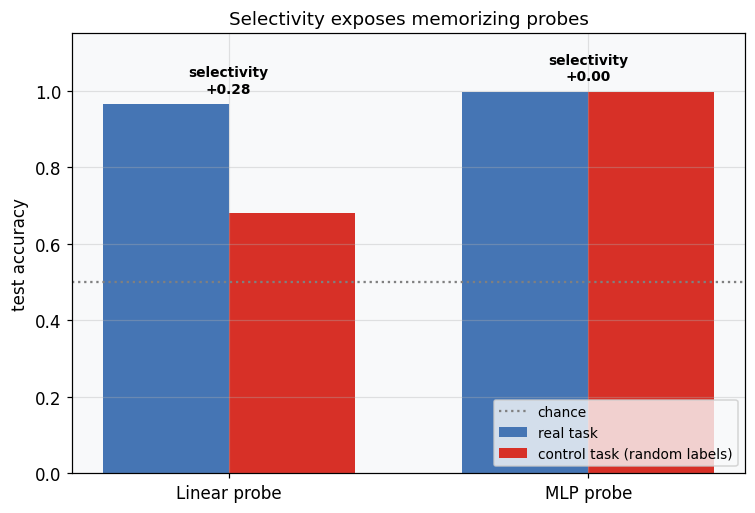

In [9]:
labels = list(res)
real_v = [res[k][0] for k in labels]
ctrl_v = [res[k][1] for k in labels]
sel_v = [r - c for r, c in zip(real_v, ctrl_v)]

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.bar(x - width / 2, real_v, width, label='real task', color='#4575b4')
ax.bar(x + width / 2, ctrl_v, width, label='control task (random labels)', color='#d73027')
for i in range(len(labels)):
    ax.annotate(f'selectivity\n{sel_v[i]:+.2f}', (x[i], max(real_v[i], ctrl_v[i]) + 0.03),
                ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.15)
ax.set_title('Selectivity exposes memorizing probes')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Both probes score high on the **real** task (blue) — fine. The difference is the **control** task
(red): the linear probe cannot memorize 60 arbitrary type→label assignments through a single
hyperplane, so its control accuracy stays low and its **selectivity is large**. The high-capacity
MLP, by contrast, carves the feature space into per-type pockets and memorizes the random labels,
so its control accuracy rises and **selectivity collapses**.

This is the core reason Latent-Anything reports *selectivity*, not raw accuracy, and prefers the
linear probe as the default introspection method: a selective probe's score is *trustworthy* — it
reflects structure in the latent, not the probe's own muscle.

## Experiment 5: The probe direction is a steering vector

**Question:** Can we *use* the concept direction $W$, not just read it?

We take the probe direction $W$ from Experiment 1, start at the "attr = 0" centroid, and walk in the
$+W$ direction. If $W$ is a genuine concept axis, the probe's predicted probability of "attr = 1"
should rise smoothly — i.e. $W$ works as a **steering vector**, the simplest form of latent
manipulation.

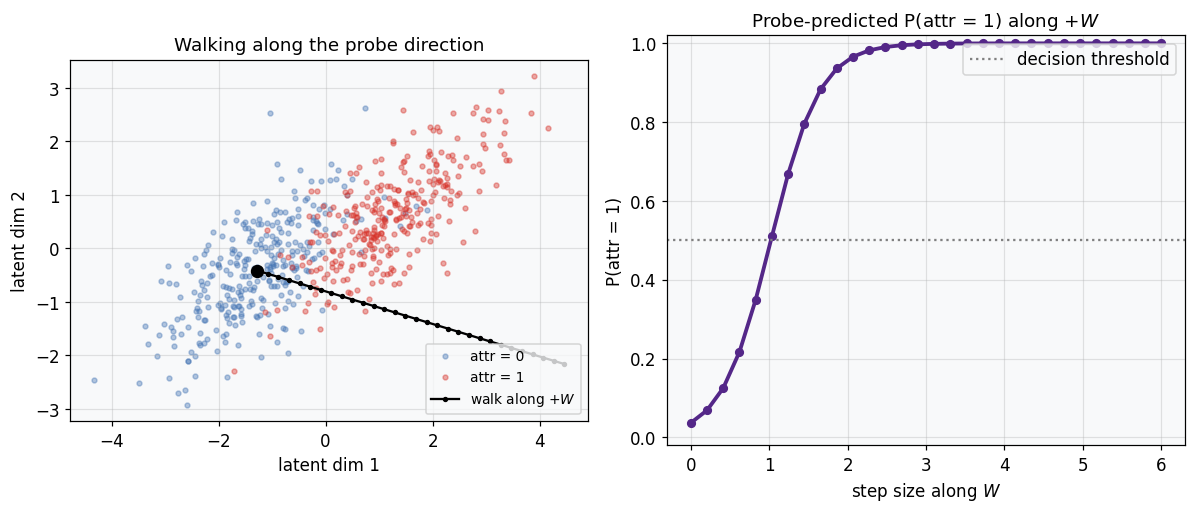

In [10]:
wn = w / np.linalg.norm(w)
z_start = z0.mean(0)
steps = np.linspace(0, 6, 30)
path = z_start + steps[:, None] * wn
probs = probe.predict_proba(path)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
# left: trajectory over the latent
ax = axes[0]
ax.scatter(z0[:, 0], z0[:, 1], s=10, c='#4575b4', alpha=0.4, label='attr = 0')
ax.scatter(z1[:, 0], z1[:, 1], s=10, c='#d73027', alpha=0.4, label='attr = 1')
ax.plot(path[:, 0], path[:, 1], 'k.-', lw=1.5, ms=5, label='walk along $+W$')
ax.scatter(*z_start, c='black', s=60, zorder=5)
ax.set_title('Walking along the probe direction')
ax.set_xlabel('latent dim 1'); ax.set_ylabel('latent dim 2')
ax.set_aspect('equal'); ax.legend(loc='lower right', fontsize=9)
# right: probability curve
ax = axes[1]
ax.plot(steps, probs, 'o-', color='#542788', lw=2.5, ms=5)
ax.axhline(0.5, color='gray', ls=':', label='decision threshold')
ax.set_title('Probe-predicted P(attr = 1) along $+W$')
ax.set_xlabel('step size along $W$'); ax.set_ylabel('P(attr = 1)')
ax.set_ylim(-0.02, 1.02); ax.legend()
plt.tight_layout(); plt.show()

### What you see

Left: starting at the blue centroid, the straight path along $+W$ marches across the boundary into
the red cluster. Right: the probe's $P(\text{attr}=1)$ climbs monotonically from ~0 to ~1 as we
step along $W$.

So the *same* vector the probe learned for **reading** the attribute also **writes** it: add
$\alpha W$ to a latent to dial the concept up. This is the bridge from Layer A (introspection) to
Layer B (manipulation) — a linear probe is the cheapest way to *discover* a steering vector, the
precursor to the dedicated steering-vector method later in this tier.

## Experiment 6 (limitation): one direction is not the whole concept

**Question:** If we delete the probe's direction, is the concept gone?

Ravfogel & Elazar et al. (2022) show probing is **unreliable for concept removal**: a concept is
often encoded *redundantly* across many directions. We build features where the label lives in a 2D
subspace, then iteratively (a) fit a linear probe, (b) project its direction out, (c) re-measure.
If one removal sufficed, accuracy would crash to chance immediately.

In [11]:
np.random.seed(6)
n, dim = 1500, 20
d1 = np.random.randn(dim); d1 /= np.linalg.norm(d1)
d2 = np.random.randn(dim)
d2 = d2 - (d2 @ d1) * d1; d2 /= np.linalg.norm(d2)   # orthogonal to d1
y6 = np.random.choice([0, 1], n)
s = (2 * y6 - 1).astype(float)
# label info spread across two independent noisy directions -> 2D signal
X6 = (np.outer(s + 0.5 * np.random.randn(n), d1)
      + np.outer(s + 0.5 * np.random.randn(n), d2)
      + 0.7 * np.random.randn(n, dim))

def fit_remove(Xr, y):
    p = LogisticRegression(max_iter=1000).fit(Xr, y)
    u = p.coef_[0]; u = u / np.linalg.norm(u)
    return p.score(Xr, y), u

Xr = X6.copy(); accs = []
for k in range(8):
    acc_k, u = fit_remove(Xr, y6)
    accs.append(acc_k)
    Xr = Xr - np.outer(Xr @ u, u)        # null the probe direction
print('accuracy after removing k directions:',
      ' '.join(f'{a:.2f}' for a in accs))

accuracy after removing k directions: 0.95 0.64 0.54 0.50 0.50 0.50 0.50 0.50


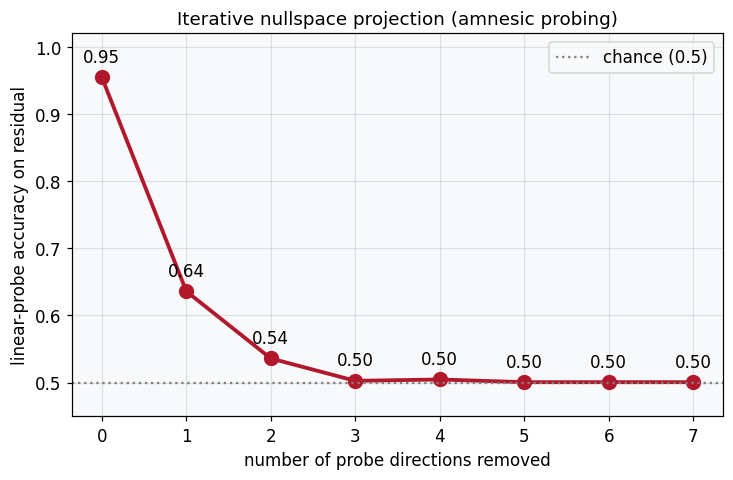

In [12]:
fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.plot(range(len(accs)), accs, 'o-', lw=2.5, ms=9, color='#b2182b')
for i, a in enumerate(accs):
    ax.annotate(f'{a:.2f}', (i, a), textcoords='offset points', xytext=(0, 10), ha='center')
ax.axhline(0.5, color='gray', ls=':', label='chance (0.5)')
ax.set_title('Iterative nullspace projection (amnesic probing)')
ax.set_xlabel('number of probe directions removed')
ax.set_ylabel('linear-probe accuracy on residual')
ax.set_ylim(0.45, 1.02); ax.legend()
plt.tight_layout(); plt.show()

### What you see

Removing the **first** probe direction barely dents accuracy — the residual still carries the label.
Only after several nullspace projections does accuracy decay toward chance, because the concept was
smeared across a multi-dimensional subspace, not a single axis.

The takeaway is a caution, not a defeat: a single linear probe finds *one* readable direction, but
that direction is **not** the concept's full footprint. Any Latent-Anything operation that tries to
*erase* an attribute (debiasing, concept ablation) must iterate (INLP-style) and verify — a
one-shot projection leaves the concept recoverable. It also reminds us that a probe proves
*decodability*, never that the model *uses* that exact direction.

## Summary / Key Takeaways

- **Exp 1** — A linear probe is a single hyperplane $Wz+b$; its weight vector $W$ is a reusable
  *concept direction*.
- **Exp 2** — Linear separability rises monotonically with depth, so probing every layer reveals
  *where* a feature becomes linearly accessible.
- **Exp 3** — Linear vs nonlinear probes answer different questions: linear tests the *geometry*
  (linearly accessible?), nonlinear tests *existence* (information present at all?).
- **Exp 4** — *Selectivity* (real − control accuracy) separates real reading from memorization;
  linear probes are selective, high-capacity probes are not — report selectivity, not raw accuracy.
- **Exp 5** — The probe direction also *writes* the concept: $z + \alpha W$ steers it, bridging
  introspection (Layer A) to manipulation (Layer B).
- **Exp 6** — One probe direction is not the whole concept; redundant encoding makes single-shot
  removal unreliable, so concept ablation must iterate and verify.
